# ARUCO markers: basics

## 1:  Marker creation

## Import Packages

In [75]:
# import the necessary packages
import matplotlib.pyplot as plt
import numpy as np
import argparse
import cv2
import sys
%matplotlib inline

## Function to display images in Jupyter Notebooks and Google Colab

In [55]:
def plt_imshow(title, image):
    # convert the image frame BGR to RGB color space and display it
	image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
	plt.imshow(image)
	plt.title(title)
	plt.grid(False)
	plt.show()

In [14]:
import cv2
import numpy as np
from cv2 import aruco

# Size and offset value
size = 150
offset = 10
x_offset = y_offset = int(offset) // 2

# get dictionary and generate image
dictionary = aruco.getPredefinedDictionary(aruco.DICT_4X4_50)
ar_img = aruco.generateImageMarker(dictionary, 0, size)

# make white image
img = np.zeros((size + offset, size + offset), dtype=np.uint8)
img += 255

# overlap image
img[y_offset:y_offset + ar_img.shape[0], x_offset:x_offset + ar_img.shape[1]] = ar_img

cv2.imwrite("./tags/marker_0.png", img)

True

In [15]:
import cv2
from cv2 import aruco

# get dicionary and get parameters
dictionary = aruco.getPredefinedDictionary(aruco.DICT_4X4_50)
parameters = aruco.DetectorParameters()

# read from image
input_file = "./tags/marker_0.png"
output_file = "./tags/detected_marker_0.png"
input_img = cv2.imread(input_file)

# detect and draw marker's information
corners, ids, rejectedCandidates = aruco.detectMarkers(input_img, dictionary, parameters=parameters)
print(ids)
ar_image = aruco.drawDetectedMarkers(input_img, corners, ids)

cv2.imwrite(output_file, ar_image)

[[0]]


True

## Implementing our ArUco marker generation script with OpenCV and Python

In [29]:
# # construct the argument parser and parse the arguments
# ap = argparse.ArgumentParser()
# ap.add_argument("-o", "--output", required=True,
# 	help="path to output image containing ArUCo tag")
# ap.add_argument("-i", "--id", type=int, required=True,
# 	help="ID of ArUCo tag to generate")
# ap.add_argument("-t", "--type", type=str,
# 	default="DICT_ARUCO_ORIGINAL",
# 	help="type of ArUCo tag to generate")
# args = vars(ap.parse_args())

# since we are using Jupyter Notebooks we can replace our argument
# parsing code with *hard coded* arguments and values
args = {
	"output": "./tags/DICT_5X5_100_id25.png",
    "id": 25,
    "type": "DICT_5X5_100",
}
    

In [30]:

# define names of each possible ArUco tag OpenCV supports
ARUCO_DICT = {
	"DICT_4X4_50": cv2.aruco.DICT_4X4_50,
	"DICT_4X4_100": cv2.aruco.DICT_4X4_100,
	"DICT_4X4_250": cv2.aruco.DICT_4X4_250,
	"DICT_4X4_1000": cv2.aruco.DICT_4X4_1000,
	"DICT_5X5_50": cv2.aruco.DICT_5X5_50,
	"DICT_5X5_100": cv2.aruco.DICT_5X5_100,
	"DICT_5X5_250": cv2.aruco.DICT_5X5_250,
	"DICT_5X5_1000": cv2.aruco.DICT_5X5_1000,
	"DICT_6X6_50": cv2.aruco.DICT_6X6_50,
	"DICT_6X6_100": cv2.aruco.DICT_6X6_100,
	"DICT_6X6_250": cv2.aruco.DICT_6X6_250,
	"DICT_6X6_1000": cv2.aruco.DICT_6X6_1000,
	"DICT_7X7_50": cv2.aruco.DICT_7X7_50,
	"DICT_7X7_100": cv2.aruco.DICT_7X7_100,
	"DICT_7X7_250": cv2.aruco.DICT_7X7_250,
	"DICT_7X7_1000": cv2.aruco.DICT_7X7_1000,
	"DICT_ARUCO_ORIGINAL": cv2.aruco.DICT_ARUCO_ORIGINAL,
	"DICT_APRILTAG_16h5": cv2.aruco.DICT_APRILTAG_16h5,
	"DICT_APRILTAG_25h9": cv2.aruco.DICT_APRILTAG_25h9,
	"DICT_APRILTAG_36h10": cv2.aruco.DICT_APRILTAG_36h10,
	"DICT_APRILTAG_36h11": cv2.aruco.DICT_APRILTAG_36h11
}

In [31]:
# verify that the supplied ArUCo tag exists and is supported by
# OpenCV
if ARUCO_DICT.get(args["type"], None) is None:
	print("[INFO] ArUCo tag of '{}' is not supported".format(
		args["type"]))
	sys.exit(0)

# load the ArUCo dictionary
arucoDict = cv2.aruco.getPredefinedDictionary(ARUCO_DICT[args["type"]])

[INFO] generating ArUCo tag type 'DICT_5X5_100' with ID '25'


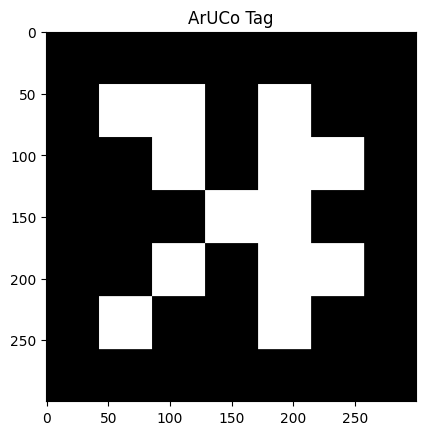

In [34]:
# allocate memory for the output ArUCo tag and then draw the ArUCo
# tag on the output image
print("[INFO] generating ArUCo tag type '{}' with ID '{}'".format(
	args["type"], args["id"]))
tag = np.zeros((300, 300, 1), dtype="uint8")
cv2.aruco.generateImageMarker(arucoDict, args["id"], 300, tag, 1)

# write the generated ArUCo tag to disk and then display it to our
# screen
cv2.imwrite(args["output"], tag)
plt_imshow("ArUCo Tag", tag)

In [61]:
# import the necessary packages
import matplotlib.pyplot as plt
import argparse
import imutils
from imutils.video import VideoStream
import time
import cv2
import sys

In [62]:
# # construct the argument parser and parse the arguments
# ap = argparse.ArgumentParser()
# ap.add_argument("-i", "--image", required=True,
# 	help="path to input image containing ArUCo tag")
# ap.add_argument("-t", "--type", type=str,
# 	default="DICT_ARUCO_ORIGINAL",
# 	help="type of ArUCo tag to detect")
# args = vars(ap.parse_args())

# since we are using Jupyter Notebooks we can replace our argument
# parsing code with *hard coded* arguments and values
args = {
    "image": "images/example_01.png",
    "type": "DICT_5X5_100",
}

In [63]:
# define names of each possible ArUco tag OpenCV supports
ARUCO_DICT = {
	"DICT_4X4_50": cv2.aruco.DICT_4X4_50,
	"DICT_4X4_100": cv2.aruco.DICT_4X4_100,
	"DICT_4X4_250": cv2.aruco.DICT_4X4_250,
	"DICT_4X4_1000": cv2.aruco.DICT_4X4_1000,
	"DICT_5X5_50": cv2.aruco.DICT_5X5_50,
	"DICT_5X5_100": cv2.aruco.DICT_5X5_100,
	"DICT_5X5_250": cv2.aruco.DICT_5X5_250,
	"DICT_5X5_1000": cv2.aruco.DICT_5X5_1000,
	"DICT_6X6_50": cv2.aruco.DICT_6X6_50,
	"DICT_6X6_100": cv2.aruco.DICT_6X6_100,
	"DICT_6X6_250": cv2.aruco.DICT_6X6_250,
	"DICT_6X6_1000": cv2.aruco.DICT_6X6_1000,
	"DICT_7X7_50": cv2.aruco.DICT_7X7_50,
	"DICT_7X7_100": cv2.aruco.DICT_7X7_100,
	"DICT_7X7_250": cv2.aruco.DICT_7X7_250,
	"DICT_7X7_1000": cv2.aruco.DICT_7X7_1000,
	"DICT_ARUCO_ORIGINAL": cv2.aruco.DICT_ARUCO_ORIGINAL,
	"DICT_APRILTAG_16h5": cv2.aruco.DICT_APRILTAG_16h5,
	"DICT_APRILTAG_25h9": cv2.aruco.DICT_APRILTAG_25h9,
	"DICT_APRILTAG_36h10": cv2.aruco.DICT_APRILTAG_36h10,
	"DICT_APRILTAG_36h11": cv2.aruco.DICT_APRILTAG_36h11
}

In [80]:
# load the input image from disk and resize it
print("[INFO] loading image...")
image = cv2.imread(args["image"])
image = imutils.resize(image, width=600)

# verify that the supplied ArUCo tag exists and is supported by
# OpenCV
if ARUCO_DICT.get(args["type"], None) is None:
	print("[INFO] ArUCo tag of '{}' is not supported".format(
		args["type"]))
	sys.exit(0)

# load the ArUCo dictionary, grab the ArUCo parameters, and detect
# the markers
print("[INFO] detecting '{}' tags...".format(args["type"]))
arucoDict = cv2.aruco.getPredefinedDictionary(ARUCO_DICT[args["type"]])
arucoParams = cv2.aruco.DetectorParameters()
detector = aruco.ArucoDetector(arucoDict, arucoParams)

[INFO] loading image...
[INFO] detecting 'DICT_5X5_100' tags...


In [81]:
# Detect the markers
markerCorners, markerIds, rejectedCandidates = detector.detectMarkers(image)

Detected marker IDs: [[24]
 [66]
 [87]
 [42]
 [ 0]
 [99]
 [70]]


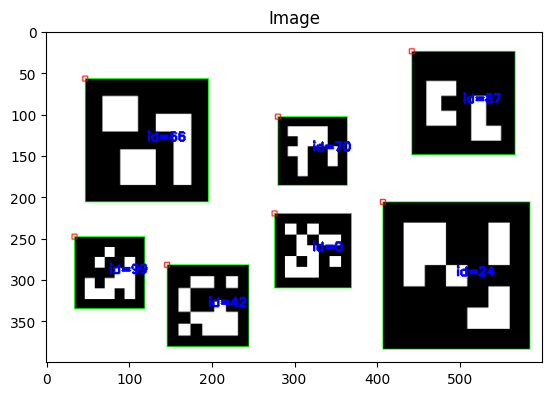

In [82]:
# Draw bounding boxes around the detected markers
if markerIds is not None:
    aruco.drawDetectedMarkers(image, markerCorners, markerIds)

    # Print marker IDs
    print("Detected marker IDs:", markerIds)

# show the output image
plt_imshow("Image", image)